# 棋盘格（Checkerboard）模型 MSE 反演

使用 `MT2DTrueModels.create_true_checkerboard` 生成高低阻交替棋盘格真实模型，并执行 2D MT 反演（MSE 损失）。

In [1]:
import os
import sys
import torch
from pathlib import Path
import numpy as np

current_path = os.path.abspath("")
root_path = os.path.abspath(os.path.join(current_path, "..", ".."))
if root_path not in sys.path:
    sys.path.insert(0, root_path)
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
from src.mt2d_inv import MT2DInverterWeightedCost, MT2DTrueModels
from src.mt2d_inv.io import ExperimentLogger

logger = ExperimentLogger(
    model_tag="rubic",#need define
    output_root=Path("test_results") #去掉parent生成test_results套ccm2d1
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on {device}")

Running on cuda


In [2]:
import os
from pathlib import Path

print(f"当前目录: {Path.cwd()}")
print(f"目录内容: {list(Path.cwd().iterdir())}")

# 检查 src 在哪里
for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (p / "src").exists():
        print(f"找到 src 在: {p}")

当前目录: /home/liuxr/MTinv_OT3/tests/synthetic
目录内容: [PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/rubic_ot_21.ipynb'), PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/.ipynb_checkpoints'), PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/commemi_2d1_ot_sparse_21_shift.ipynb'), PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/test_results'), PosixPath('/home/liuxr/MTinv_OT3/tests/synthetic/rubic_mse_21.ipynb')]
找到 src 在: /home/liuxr/MTinv_OT3


In [3]:
yn_np, zn_np, nza = MT2DTrueModels._default_grid(nza=10)

# 2) 生成真实的交替棋盘格
sig_true = MT2DTrueModels.create_true_checkerboard(
    yn=yn_np,
    zn=zn_np,
    nza=nza,
    device=device,
    bg_rho=100.0,               # 背景电阻率
    rho_1=10.0,                 # 低阻块 (10 Ohm.m)
    rho_2=1000.0,               # 高阻块 (1000 Ohm.m)
    y_bounds=(-15000.0, 15000.0), # 横向范围匹配 stations
    dy_block=10000.0,           # 约 3×3 棋盘格：每块宽 10 km
    z_bounds=(2000.0, 22000.0),   # 深度 2 km 开始，向下延伸到 22 km
    dz_block=6667.0,            # 约 3×3 棋盘格：每块高约 6.7 km
)

# 转换为 tensor 以备正反演使用
yn = torch.tensor(yn_np, device=device)
zn = torch.tensor(zn_np, device=device)

# 3) Survey setup
freqs = torch.logspace(0, -5, 30, device=device)
stations = torch.linspace(-15000.0, 15000.0, 21, device=device)

print(f"Grid (nz, ny): {(len(zn)-1, len(yn)-1)}")
print(f"Stations: {len(stations)}, Freqs: {len(freqs)}")

PLOT_KWARGS = dict(
    cmap="jet_r",
    clip_to_stations=True,
    ylim=[50, 0],
    vmin=1,
    vmax=3,
    synthetic_figwidth_scale=2.0,
)

Grid (nz, ny): (40, 40)
Stations: 21, Freqs: 30


✓ Random seed set: 123
✓ Sinkhorn (custom cost): blur=0.0100, scaling=0.9
✓ Sinkhorn OT Loss (weighted): w_s=1.0, w_f=1.0, w_d=(1.0, 1.0, 1.0, 1.0), blur=0.0100, scale=0.9, reach=None
Generating 2D MT synthetic data...


/tmp/ipykernel_3336515/2159404610.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  yn=torch.tensor(yn, dtype=torch.float64, device=device),
/tmp/ipykernel_3336515/2159404610.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  zn=torch.tensor(zn, dtype=torch.float64, device=device),


✓ XY mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ YX mode error propagation completed
   rho(log10) noise mean: 0.0087
   phi(normalized) noise mean: 0.0064
✓ 2D data error propagation completed
Computing data weights (Target Noise: 1.0%)
  - Resistivity Error Floor: 1.0%
  - Phase Error Floor:       0.500 deg
✓ MSE data weights normalized (mean): scale=5.843286e+01
✓ Synthetic data generated
  -> Impedance noise level: 1.0% (gaussian)
✓ Model initialization complete: Uniform.
  - Air layer fixed: nza=10, air_sigma=1.00e-10 S/m


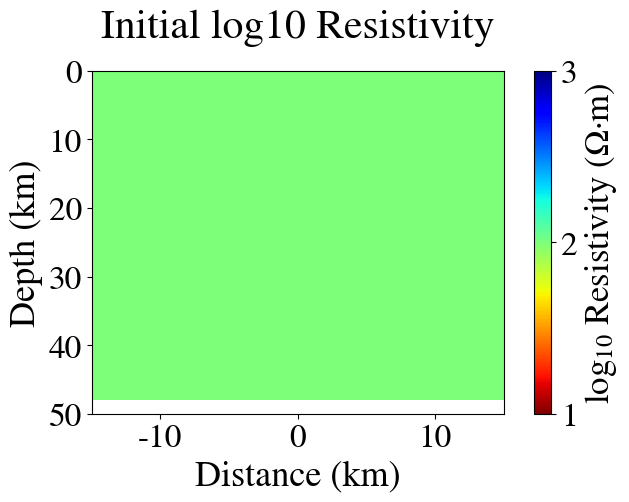

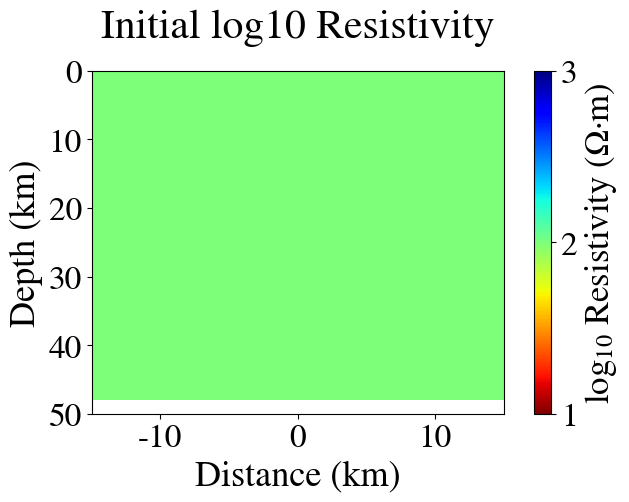

In [4]:
# 3) Inverter + synthetic data
inv = MT2DInverterWeightedCost(
    yn=torch.tensor(yn, dtype=torch.float64, device=device),
    zn=torch.tensor(zn, dtype=torch.float64, device=device),
    nza=nza,
    freqs=freqs,
    stations=stations,
    device=device,
    random_seed=123,
    te_weight=1.0,
    tm_weight=1.0,
    data_loss_scale=20,
)
inv.set_forward_operator()
inv.sig_true = sig_true
inv.create_synthetic_data(noise_level=0.01,
                        noise_type="gaussian",
                        static_shift_std=0.15,   # 0.15 会导致电阻率发生约半个量级的剧烈上下平移
                        shift_modes=("xy", "yx"),# 作用于双极化模式 (TM 模式通常对畸变最敏感)
                        shift_stations="random",
                        shift_ratio = 0)
inv.initialize_model(initial_sigma=0.01)
inv.plot_initial_model(**PLOT_KWARGS)

In [5]:
# 4) Run inversion
final_sigma = inv.run_inversion(
    n_epochs=300,
    mode="6dot",
    progress_interval=20,
    current_lambda=0.1,
    use_adaptive_lambda=True,
    lr=0.03,
    update_interval=10,
    norm_type="L2",
    alpha=0.5,
    use_depth_weights=True,
    rms_chi2_stop=1.05,
    profile_timing = False
)
print("Inversion done")
print(final_sigma.min().item(), final_sigma.max().item())

✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
✓ Optimizer: AdamW, lr=0.03, weight_decay=0.0
Epoch 1/300 [   0.3%]
  Elapsed: 0:00:02 | Remaining: ~0:07:36 | ETA: 22:34:17
  Epoch time: 1.53s | Avg: 1.53s
  Total: 4.9814e-01 | Data(6dot): 4.9814e-01
  [Cost weights] w_s=1.000, w_f=1.000, w_d=(1.0, 1.0, 1.0, 1.0)
  Misfit(RMS χ²): 42.908 | Rough: 0.00e+00 | Lam: 0.1000000
  OT-distance(6D, view-only): 4.981412e-01
  GradNorms: |g_d|=nan | |λ·g_m|=nan
 [Auto-Lambda] Epoch 10: Adjusted 1.00e-01 -> 2.09e-02 (ratio=4.353e-02)
 [Auto-Lambda] Epoch 20: Adjusted 2.09e-02 -> 9.00e-03 (ratio=1.860e-01)
Epoch 21/300 [   7.0%]
  Elapsed: 0:00:35 | Remaining: ~0:07:41 | ETA: 22:34:55
  Epoch time: 2.04s | Avg: 1.65s
  Total: 2.5778e-01 | Data(6dot): 2.3931e-01
  Misfit(RMS χ²): 26.616 | Rough: 2.05e+00 | Lam: 0.0089984
  OT-distance(6D, view-only): 2.393055e-01
  GradNorms: |g_d|=1.048e-03 | |λ·g_m|=1.319e-03
 [Auto-Lambda] Epoch 30: Adjusted 9.00e-03 -> 4.75e-03 (ratio=2.792e-01)
 [Auto-Lambda] Epo

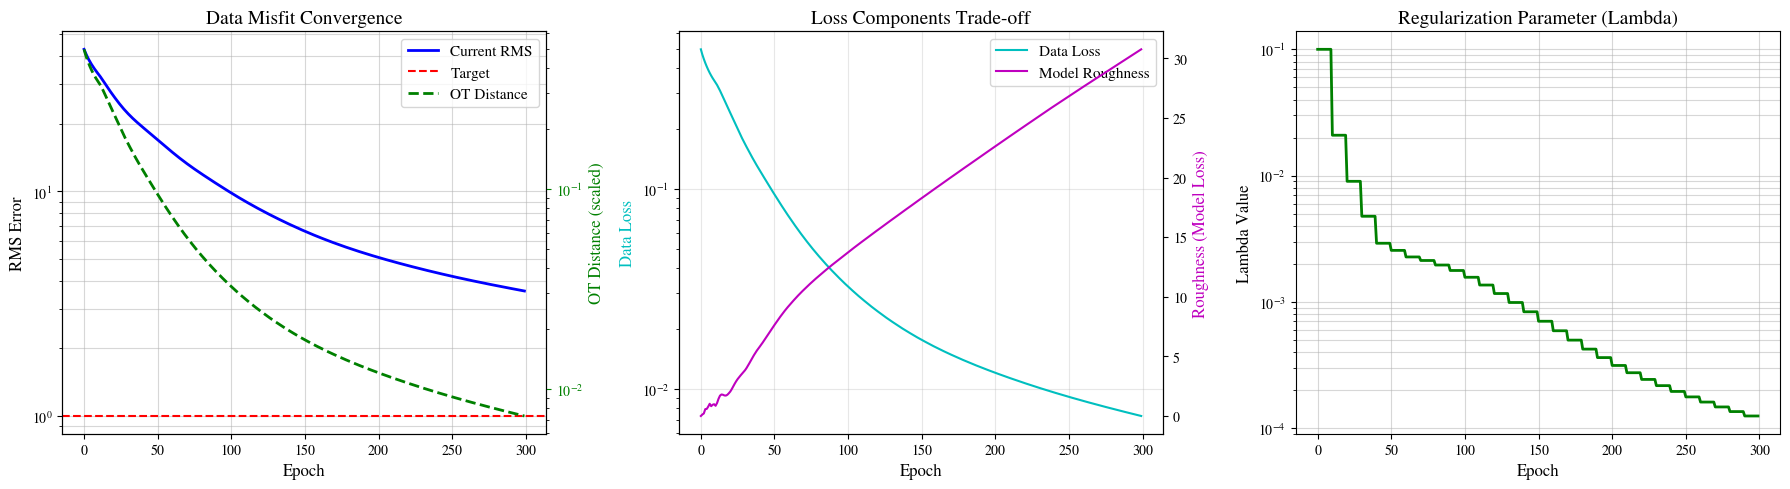

Model structural similarity (SSIM): 0.7890


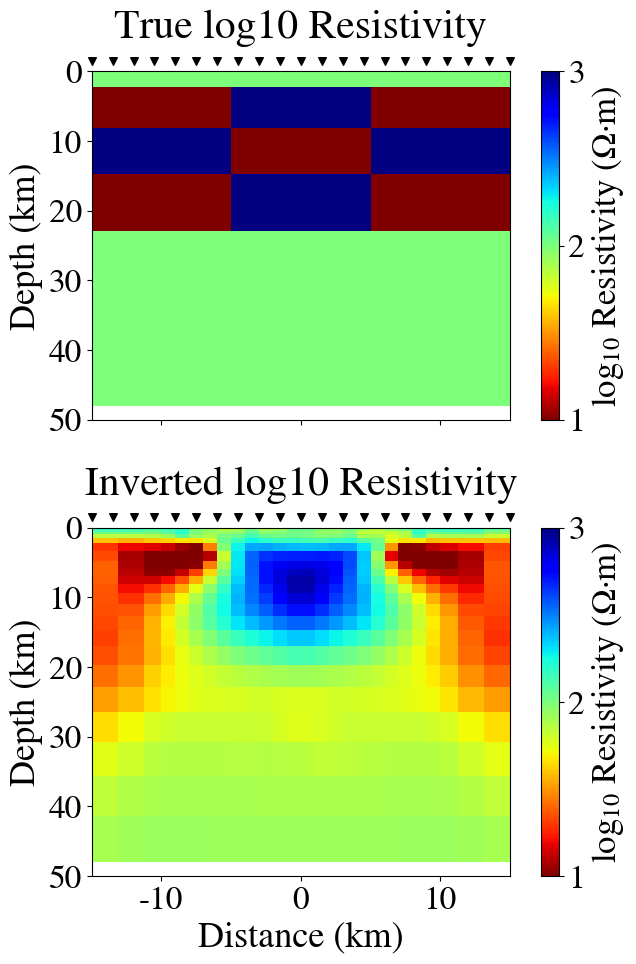

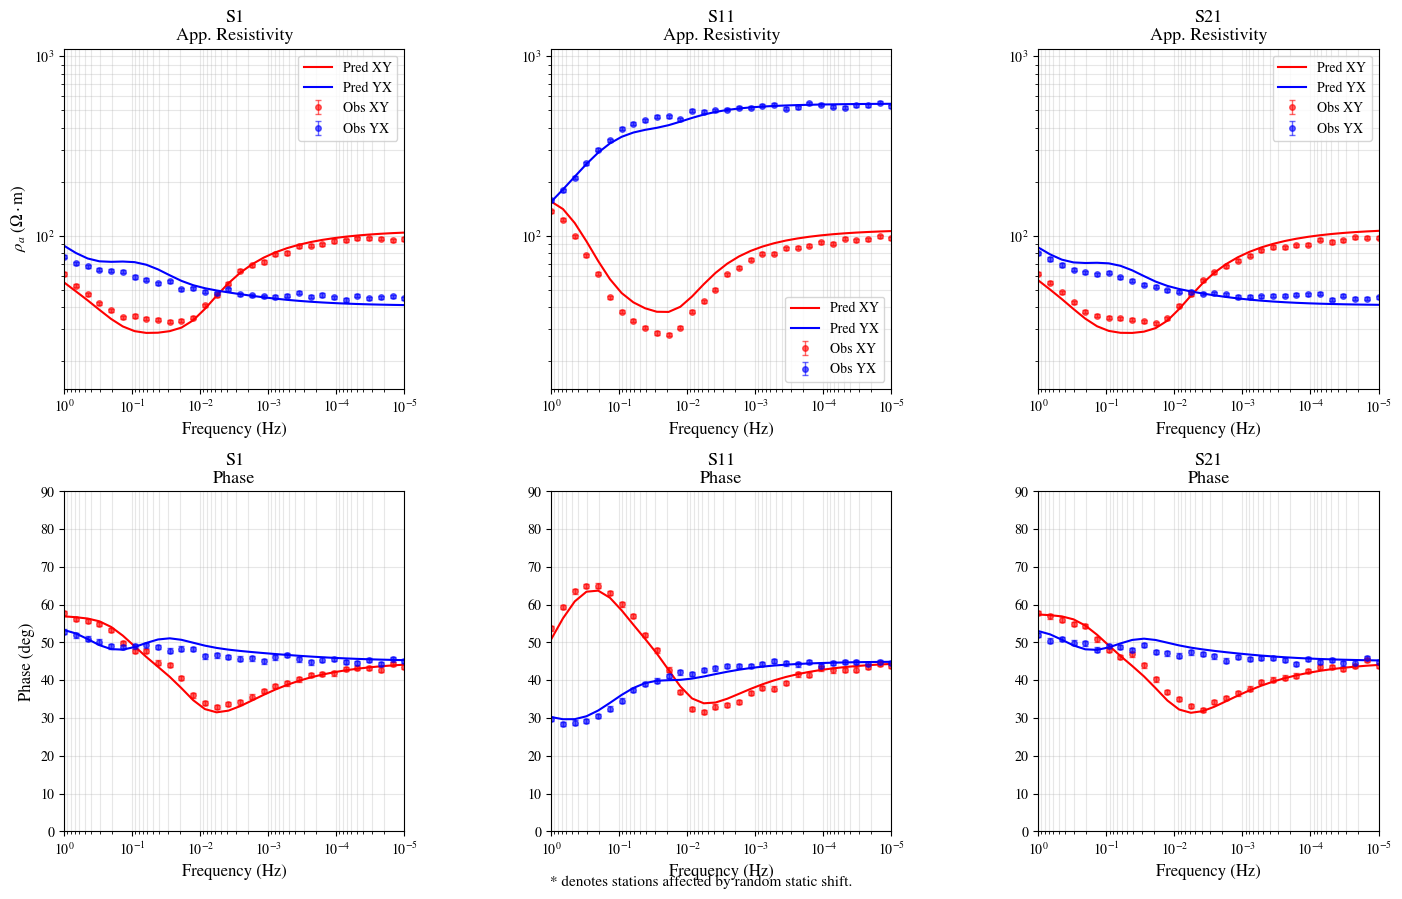

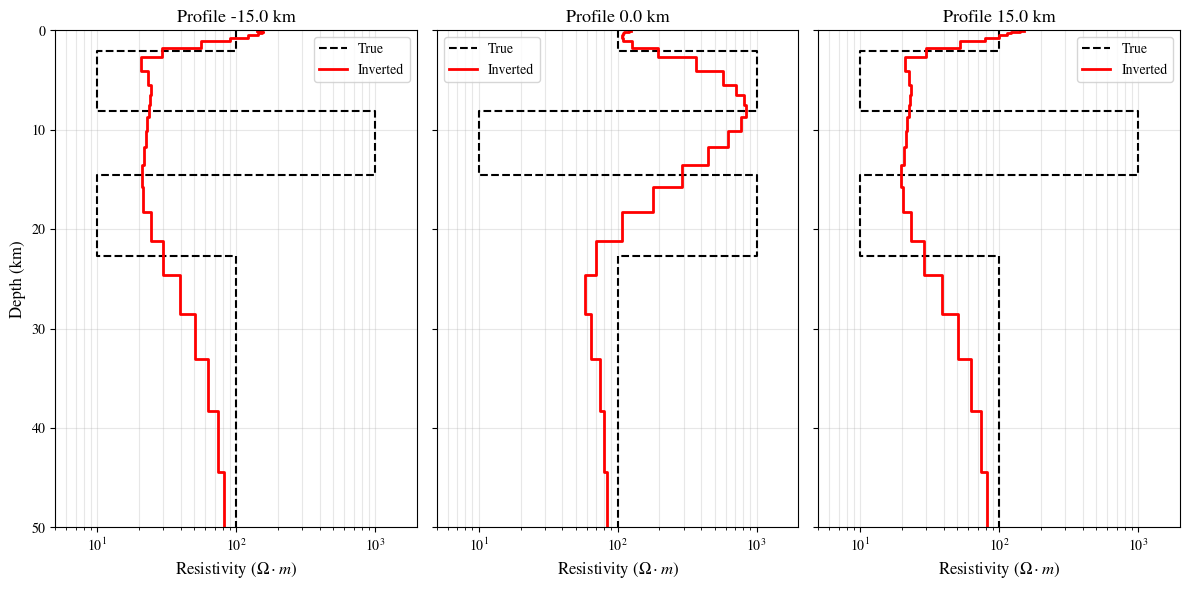

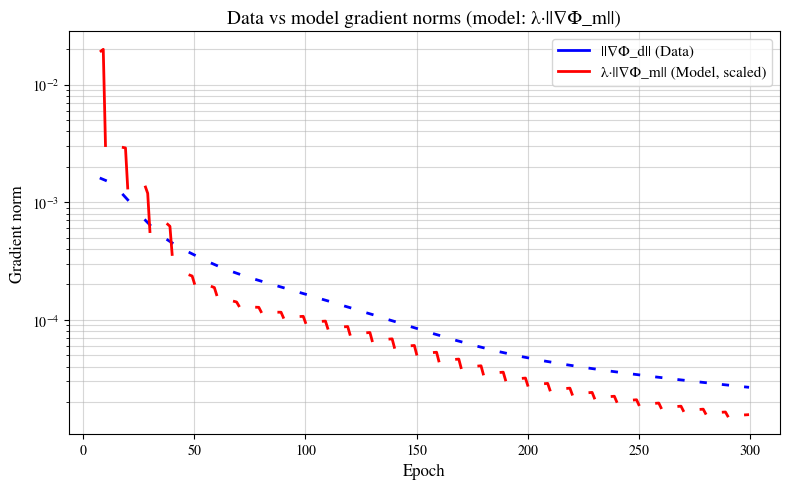

In [6]:
# 5) Plot results
inv.plot_loss_history()
inv.plot_model_comparison(**PLOT_KWARGS)
inv.plot_data_fitting()
inv.plot_1d_profiles(depth_limit_km=50)
inv.plot_gradient_history()

In [7]:
logger.save_from_inverter(
    inv,
    run_name="rubic_ot",
    plot_kwargs=PLOT_KWARGS,
)



Saving results to: test_results/rubic/2026-07-05_22-35-03_rubic_ot
  ✓ summary.csv
  ✓ history.csv
  ✓ config.json
  ✓ timing.json
  ✓ meta.json
  ✓ final_model.npz
  ✓ static_shift.json
  ✓ apparent_resistivity.npz
Model structural similarity (SSIM): 0.7890
  ✓ Figures saved to test_results/rubic/2026-07-05_22-35-03_rubic_ot/figures

Results saved successfully!
  Location: test_results/rubic/2026-07-05_22-35-03_rubic_ot
  Final RMS χ²: 3.6017
  RMSE: 0.5274
  MAPE: 19.68%



PosixPath('test_results/rubic/2026-07-05_22-35-03_rubic_ot')

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>